<a href="https://colab.research.google.com/github/laniquahendricks2/laniquahendricks2.github.io/blob/main/UNICEF_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: "🌍 A Global Gap in Access to Life-Saving Treatment"
author: "Laniqua Hendricks"

format:
  html:
    theme: cosmo
    embed-resources: true
    number-sections: false
    toc: true
    include-in-header:
      text: |
        <style>
        body {
          background-color: #f6fbf7;
          font-family: "Segoe UI", sans-serif;
        }

        main.content {
          background-color: white;
          padding: 2rem;
          border-radius: 16px;
          box-shadow: 0 4px 14px rgba(0, 0, 0, 0.08);
        }

        h1 {
          color: #1b5e20;
          font-weight: 700;
        }

        h2 {
          color: #2e7d32;
          margin-top: 2rem;
        }

        .callout {
          border-radius: 12px;
        }

        img {
          border-radius: 12px;
        }
        </style>

execute:
  echo: false
  warning: false
  message: false
---
<div style="text-align:center; margin-top:1rem; margin-bottom:1.8rem; max-width:700px; margin-left:auto; margin-right:auto;">
  <div style="font-size:1.15rem; font-weight:600; color:#1b5e20; line-height:1.5; white-space:normal;">
    More than 1,300 children die every day from diarrhoea related illnesses.
  </div>
  <div style="font-size:0.95rem; color:#555; margin-top:0.5rem; line-height:1.4;">
    Effective treatment exists, but access remains unequal.
  </div>
</div>

In [ ]:
from IPython.display import HTML

HTML('''
<style>
img {
  transition: transform 0.3s ease;
}

img:hover {
  transform: scale(1.02);
}
</style>
''')

In [ ]:
#| include: false
!pip install polars plotnine quarto-cli

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.7 MB/s eta 0:00:00
  Created wheel for quarto-cli: filename=quarto_cli-1.9.36-py3-none-any.whl size=137901175 sha256=fbbfd7ecbc9459bb3a1d4183e787ed26f6afe6d9deb0cb5d022f5f6893ac3bb5
  Stored in directory: /root/.cache/pip/wheels/8d/25/8a/da0c6adda7e50c7c50c9afd6a372250fb4b306b331ba834333
Successfully built quarto-cli


In [ ]:
#| include: false
indicator = pl.read_csv("unicef_indicator_2.csv")
metadata = pl.read_csv("unicef_metadata.csv")

In [ ]:
#| include: false
print("Indicator shape:", indicator.shape)
print("Metadata shape:", metadata.shape)

print("Number of countries:", indicator.select(pl.col("country").n_unique()).item())

print("Years available:")
print(
    indicator
    .select("time_period")
    .unique()
    .sort("time_period")
)

Indicator shape: (598, 14)
Metadata shape: (13715, 15)
Number of countries: 92
Years available:
shape: (20, 1)
┌─────────────┐
│ time_period │
│ ---         │
│ i64         │
╞═════════════╡
│ 2005        │
│ 2006        │
│ 2007        │
│ 2008        │
│ 2009        │
│ …           │
│ 2020        │
│ 2021        │
│ 2022        │
│ 2023        │
│ 2024        │
└─────────────┘


In [ ]:
#| include: false
latest_country.select([
    pl.col("obs_value").null_count().alias("Missing treatment values")
])

Missing treatment values
u32
0


In [ ]:
#| include: false
highest = (
    latest_country
    .sort("obs_value", descending=True)
    .head(3)
    .select(["country", "obs_value"])
)

lowest = (
    latest_country
    .sort("obs_value")
    .head(3)
    .select(["country", "obs_value"])
)

print(highest)
print(lowest)

shape: (3, 2)
┌─────────────────────────────────┬───────────┐
│ country                         ┆ obs_value │
│ ---                             ┆ ---       │
│ str                             ┆ f64       │
╞═════════════════════════════════╪═══════════╡
│ Bolivia                         ┆ 60.2      │
│ Sierra Leone                    ┆ 53.4      │
│ Korea, Democratic People's Rep… ┆ 45.0      │
└─────────────────────────────────┴───────────┘
shape: (3, 2)
┌───────────┬───────────┐
│ country   ┆ obs_value │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ Sri Lanka ┆ 0.0       │
│ Peru      ┆ 0.2       │
│ Namibia   ┆ 0.2       │
└───────────┴───────────┘


In [ ]:
#| include: false
print(indicator.columns)
print(metadata.columns)

['country', 'alpha_2_code', 'alpha_3_code', 'numeric_code', 'indicator', 'time_period', 'obs_value', 'sex', 'unit_multiplier', 'unit_of_measure', 'observation_status', 'observation_confidentaility', 'time_period_activity_related_to_when_the_data_are_collected', 'current_age']
['country', 'alpha_2_code', 'alpha_3_code', 'numeric_code', 'year', 'Population, total', 'GDP per capita (constant 2015 US$)', 'GNI (current US$)', 'Inflation, consumer prices (annual %)', 'Life expectancy at birth, total (years)', 'Military expenditure (% of GDP)', 'Fossil fuel energy consumption (% of total)', 'GDP growth (annual %)', 'Birth rate, crude (per 1,000 people)', 'Hospital beds (per 1,000 people)']


In [ ]:
#| include: false
latest_year = indicator["time_period"].max()
print(latest_year)

2024


In [ ]:
#| include: false
latest = indicator.filter(pl.col("time_period") == latest_year)

latest.select(["country", "obs_value"]).head()

country,obs_value
str,f64
"""Lesotho""",9.5
"""Lesotho""",11.2
"""Lesotho""",10.4
"""Mali""",3.3
"""Mali""",3.5


In [ ]:
#| include: false
latest_total = latest.filter(pl.col("sex") == "Total")

latest_total.select(["country", "obs_value"]).head()

country,obs_value
str,f64
"""Lesotho""",10.4
"""Mali""",3.4
"""Nigeria""",23.6
"""Zambia""",38.4


In [ ]:
#| include: false
top10 = (
    latest_total
    .sort("obs_value", descending=True)
    .head(10)
)

top10.select(["country", "obs_value"])

country,obs_value
str,f64
"""Zambia""",38.4
"""Nigeria""",23.6
"""Lesotho""",10.4
"""Mali""",3.4


In [ ]:
#| include: false
bottom10 = (
    latest_total
    .sort("obs_value")
    .head(10)
)

bottom10.select(["country", "obs_value"])

country,obs_value
str,f64
"""Mali""",3.4
"""Lesotho""",10.4
"""Nigeria""",23.6
"""Zambia""",38.4


In [ ]:
#| include: false
latest_total_year = latest_total.rename({"time_period": "year"})

In [ ]:
#| include: false
scatter_data = latest_total_year.join(
    metadata,
    on=["country", "year"],
    how="inner"
)

In [ ]:
#| include: false
scatter_data.select([
    "country",
    "year",
    "obs_value",
    "GDP per capita (constant 2015 US$)"
]).head()

country,year,obs_value,GDP per capita (constant 2015 US$)
str,i64,f64,f64
"""Lesotho""",2024,10.4,991.069662
"""Mali""",2024,3.4,909.755318
"""Nigeria""",2024,23.6,2324.648812
"""Zambia""",2024,38.4,1343.389664


In [ ]:
#| include: false
latest_country = (
    indicator
    .filter(pl.col("sex") == "Total")
    .sort(["country", "time_period"])
    .group_by("country")
    .tail(1)
)

In [ ]:
#| include: false
latest_country = (
    indicator
    .filter(pl.col("sex") == "Total")
    .sort("time_period")
    .group_by("country")
    .agg([
        pl.col("time_period").last().alias("year"),
        pl.col("obs_value").last().alias("obs_value")
    ])
)

latest_country.head()

country,year,obs_value
str,i64,f64
"""Armenia""",2016,2.0
"""Malawi""",2020,22.0
"""Gambia""",2020,21.1
"""Iraq""",2018,5.2
"""El Salvador""",2021,29.4


In [ ]:
#| include: false
scatter_data = latest_country.join(
    metadata,
    on=["country", "year"],
    how="inner"
)

scatter_data.select([
    "country",
    "year",
    "obs_value",
    "GDP per capita (constant 2015 US$)"
]).head()

country,year,obs_value,GDP per capita (constant 2015 US$)
str,i64,f64,f64
"""Afghanistan""",2023,24.0,378.066303
"""Albania""",2018,7.4,4893.823755
"""Armenia""",2016,2.0,3533.885036
"""Azerbaijan""",2023,9.6,5668.610213
"""Bangladesh""",2019,35.0,1564.208024


In [ ]:
#| include: false
print(scatter_data.shape)
scatter_data.head()

(91, 16)


country,year,obs_value,alpha_2_code,alpha_3_code,numeric_code,"Population, total",GDP per capita (constant 2015 US$),GNI (current US$),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Military expenditure (% of GDP),Fossil fuel energy consumption (% of total),GDP growth (annual %),"Birth rate, crude (per 1,000 people)","Hospital beds (per 1,000 people)"
str,i64,f64,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Afghanistan""",2023,24.0,"""AF""","""AFG""",4,41454761,378.066303,1.7235e10,-4.644709,66.035,null,null,2.266944,35.437,0.35
"""Albania""",2018,7.4,"""AL""","""ALB""",8,2607733,4893.823755,1.5362e10,2.02806,79.238,1.160545,0.0,3.671419,10.898,2.83
"""Armenia""",2016,2.0,"""AM""","""ARM""",51,2992300,3533.885036,1.0791e10,-1.403608,74.868293,4.090349,0.0,0.2,13.5,4.28
"""Azerbaijan""",2023,9.6,"""AZ""","""AZE""",31,10153958,5668.610213,6.9386e10,8.78543,74.429,4.922414,0.0,1.354477,11.1,3.68
"""Bangladesh""",2019,35.0,"""BD""","""BGD""",50,164913055,1564.208024,3.6562e11,5.591996,72.625,1.244101,0.0,7.881915,20.131,0.89


## 🚨 Introduction

Diarrhoea remains one of the leading causes of death among children under five, even though effective treatment is simple, inexpensive, and widely recommended. Oral rehydration salts and zinc can prevent severe dehydration and save lives, yet many children still do not receive them.

Behind these missed treatments are thousands of preventable deaths each year. While progress has been made, access to life saving care remains deeply unequal, making childhood diarrhoea not only a health issue, but also a story of inequality.

![Children receiving oral rehydration salts and zinc treatment.](child_treatment.jpg)

::: {.callout-important}
## 💡 Did you know?

More than 500,000 children under five die each year from diarrhoea related illnesses, even though simple, inexpensive treatment could prevent many of these deaths.
:::

In [ ]:
from IPython.display import HTML

HTML('<hr style="border: none; height: 2px; background: linear-gradient(to right, #66bb6a, #c8e6c9); margin-top: 0.5rem; margin-bottom: 0.5rem;">')

## 📊 What does the data show?

The UNICEF dataset measures the percentage of children under five with diarrhoea who receive both oral rehydration salts (ORS) and zinc between 2005 and 2024. Treatment coverage varies widely across countries. While the average rate is approximately 16 percent, most countries report much lower levels, with a median of just 10.7 percent. Reported values range from 0 percent in Sri Lanka to 60.2 percent in Bolivia, highlighting the large differences in access to life saving treatment.

In [ ]:
#| echo: false

from IPython.display import display

summary_stats = latest_country.select([
    pl.col("obs_value").mean().alias("Average treatment rate"),
    pl.col("obs_value").median().alias("Median treatment rate"),
    pl.col("obs_value").min().alias("Minimum treatment rate"),
    pl.col("obs_value").max().alias("Maximum treatment rate")
])

display(summary_stats.to_pandas().style.hide(axis="index"))

Average treatment rate,Median treatment rate,Minimum treatment rate,Maximum treatment rate
15.970652,10.700000,0.000000,60.200000


In [ ]:
#| include: false
!pip install geopandas

In [ ]:
#| include: false
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#| include: false
latest_map = latest_country.to_pandas()

In [ ]:
#| include: false
import geopandas as gpd

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

In [ ]:
#| include: false
latest_map = latest_country.to_pandas()

world_data = world.merge(
    latest_map,
    left_on="NAME",
    right_on="country",
    how="left"
)

In [ ]:
from IPython.display import HTML

HTML('<hr style="border: none; height: 2px; background: linear-gradient(to right, #66bb6a, #c8e6c9); margin-top: 0.5rem; margin-bottom: 0.5rem;">')

## 🌍 Global Patterns in Treatment Coverage

The map reveals striking differences in access to life saving treatment across countries. Some countries report relatively high levels of treatment coverage, while others continue to provide treatment to only a small share of children with diarrhoea. Large areas of the world also have no available data, highlighting that many children remain invisible within global health statistics.

Treatment coverage does not follow a clear geographic pattern and often differs even between neighbouring countries. This suggests that access is shaped not only by wealth, but also by differences in health services, public health priorities, and the availability of oral rehydration salts and zinc.

::: {.callout-tip}
## How to read this map

Darker green countries have higher levels of treatment coverage among children with diarrhoea. Lighter countries indicate lower coverage, while grey countries have no available data.
:::

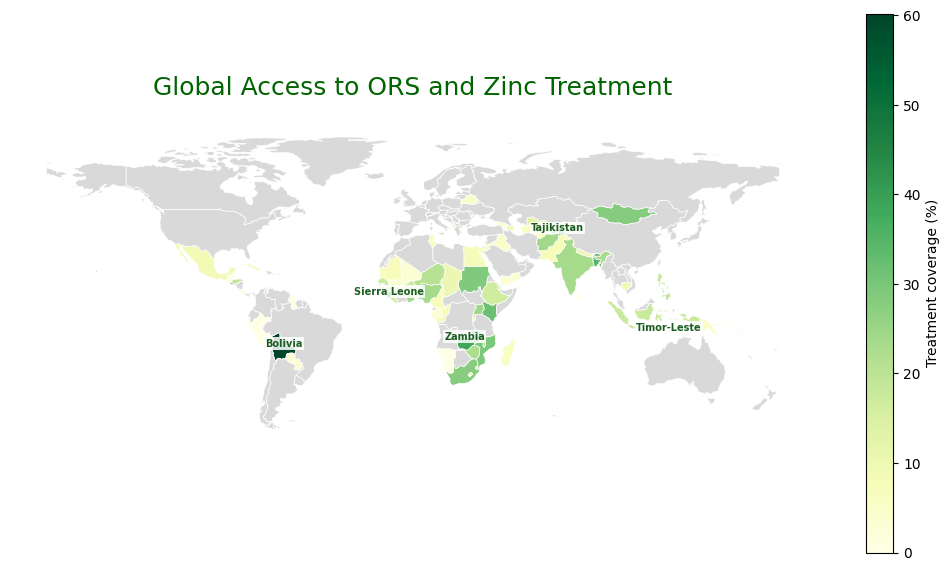

In [ ]:
#| label: fig-world-map
#| echo: false
#| fig-cap: "Treatment coverage varies substantially across countries, with some reporting much higher coverage than others."

# Ensure `latest_country` is defined
indicator = pl.read_csv("/content/unicef_indicator_2.csv")
latest_country = (
    indicator
    .filter(pl.col("sex") == "Total")
    .sort("time_period")
    .group_by("country")
    .agg([
        pl.col("time_period").last().alias("year"),
        pl.col("obs_value").last().alias("obs_value")
    ])
)

# Prepare latest_map
latest_map = latest_country.to_pandas()

# Load world data
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Merge world and latest_map to create world_data
world_data = world.merge(
    latest_map,
    left_on="NAME",
    right_on="country",
    how="left"
)

fig, ax = plt.subplots(figsize=(13, 7))

world_data_clean = world_data[world_data["NAME"] != "Antarctica"]

world_data_clean.plot(
    column="obs_value",
    cmap="YlGn",
    edgecolor="white",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Treatment coverage (%)"},
    missing_kwds={"color": "#d9d9d9"},
    ax=ax
)

# Select the top 5 countries for cleaner annotation
top5 = (
    world_data_clean[world_data_clean["country"] != "Bhutan"]
    .nlargest(5, "obs_value")
)

for _, row in top5.iterrows():
    point = row.geometry.representative_point()
    ax.text(
        point.x,
        point.y,
        row["country"],
        fontsize=7,
        fontweight="bold",
        ha="center",
        color="#1b5e20",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=1)
    )

ax.set_title(
    "Global Access to ORS and Zinc Treatment",
    fontsize=18,
    color="darkgreen",
    pad=20
)

ax.axis("off")
plt.show()

## 🌟 Country Spotlight: Bolivia and Sierra Leone

Bolivia reports the highest treatment coverage at 60.2 percent, followed by Sierra Leone at 53.4 percent. Both countries stand out for achieving much higher coverage than most others, showing that strong progress is possible even in lower income settings.

In [ ]:
#| include: false
top10 = (
    latest_country
    .sort("obs_value", descending=True)
    .head(10)
)

In [ ]:
from IPython.display import HTML

HTML('<hr style="border: none; height: 2px; background: linear-gradient(to right, #66bb6a, #c8e6c9); margin-top: 0.5rem; margin-bottom: 0.5rem;">')

## 📈 Highest Treatment Coverage in 2024

While treatment coverage remains low in many countries, a small number stand out for achieving much higher rates. The chart below shows the ten countries with the highest reported coverage of oral rehydration salts and zinc treatment in 2024, highlighting how access to life saving care differs across countries.

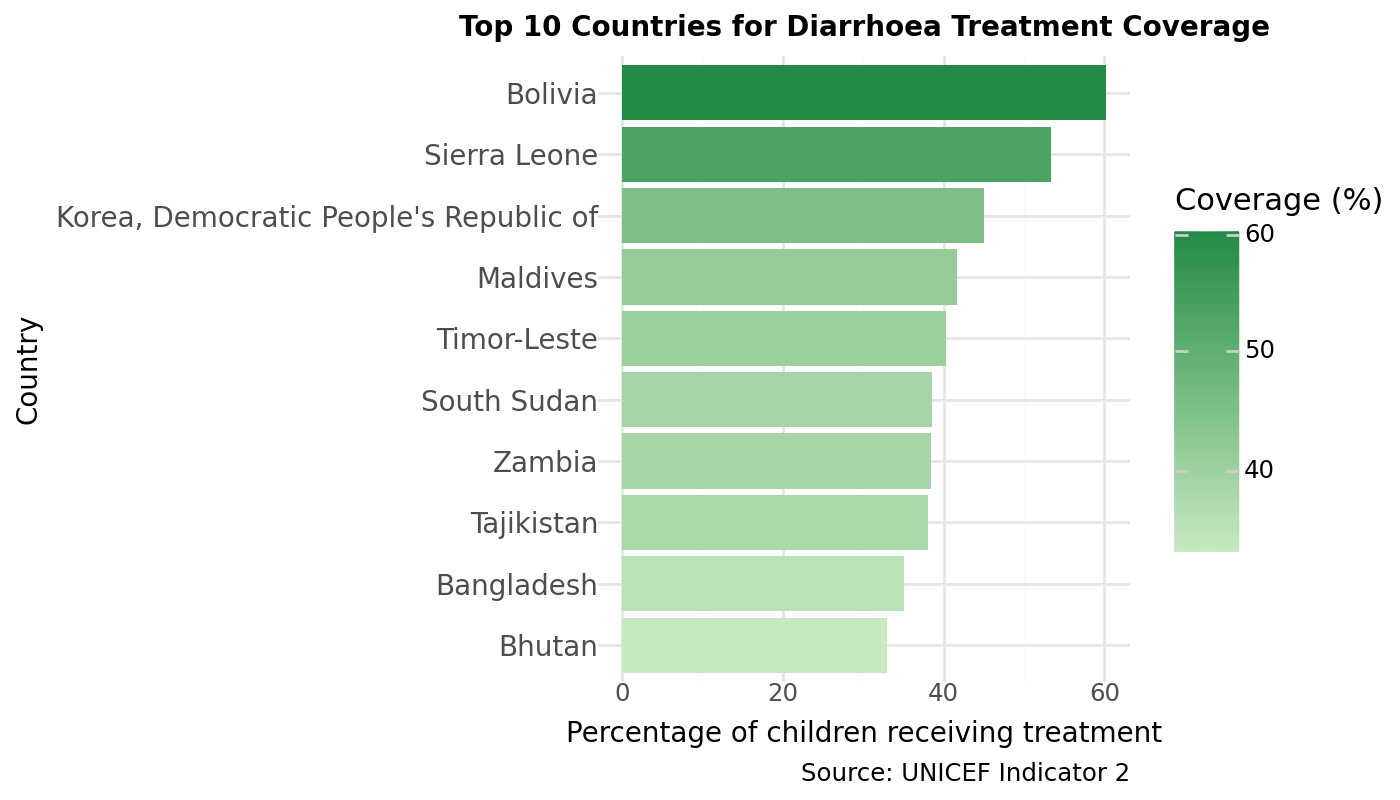

In [ ]:
#| echo: false
#| label: fig-top10
#| fig-cap: "Bolivia and Sierra Leone report the highest treatment coverage, although even the best performing countries still leave many children without treatment."
from plotnine import ggplot, aes, geom_col, coord_flip, scale_fill_gradient, labs, theme_minimal, element_text, theme

# Ensure latest_country is defined if this cell is run independently
# Based on the kernel state, latest_country is already available as a Polars DataFrame

top10 = (
    latest_country
    .sort("obs_value", descending=True)
    .head(10)
)

(    ggplot(
        top10.to_pandas(),
        aes(
            x="reorder(country, obs_value)",
            y="obs_value",
            fill="obs_value"
        )
    )
    + geom_col()
    + coord_flip()
    + scale_fill_gradient(low="#C7E9C0", high="#238B45")
    + labs(
        title="Top 10 Countries for Diarrhoea Treatment Coverage",
        x="Country",
        y="Percentage of children receiving treatment",
        fill="Coverage (%)",
        caption="Source: UNICEF Indicator 2"
    )
    + theme_minimal()
    + theme(
        figure_size=(7,4),
        plot_title=element_text(size=10, weight="bold"),
        plot_subtitle=element_text(size=11),
        axis_title=element_text(size=10),
        axis_text_y=element_text(size=10),
        legend_position="right"
    )
)

The chart shows that Bolivia and Sierra Leone lead all other countries in treatment coverage, with rates above 50 percent. However, even among the top ten countries, coverage remains below 60 percent, meaning that a large share of children with diarrhoea still do not receive recommended treatment. The presence of countries such as South Sudan, Bangladesh, and Bhutan among the highest performers suggests that strong treatment coverage is possible across a wide range of contexts.

In [ ]:
from IPython.display import HTML

HTML('<hr style="border: none; height: 2px; background: linear-gradient(to right, #66bb6a, #c8e6c9); margin-top: 0.5rem; margin-bottom: 0.5rem;">')

## 💰 Does Wealth Improve Treatment Access?

Higher national income is often assumed to improve access to healthcare, but this relationship is not always straightforward. By combining treatment coverage data with GDP per capita for the same year, it is possible to examine whether children in wealthier countries are more likely to receive oral rehydration salts and zinc treatment.

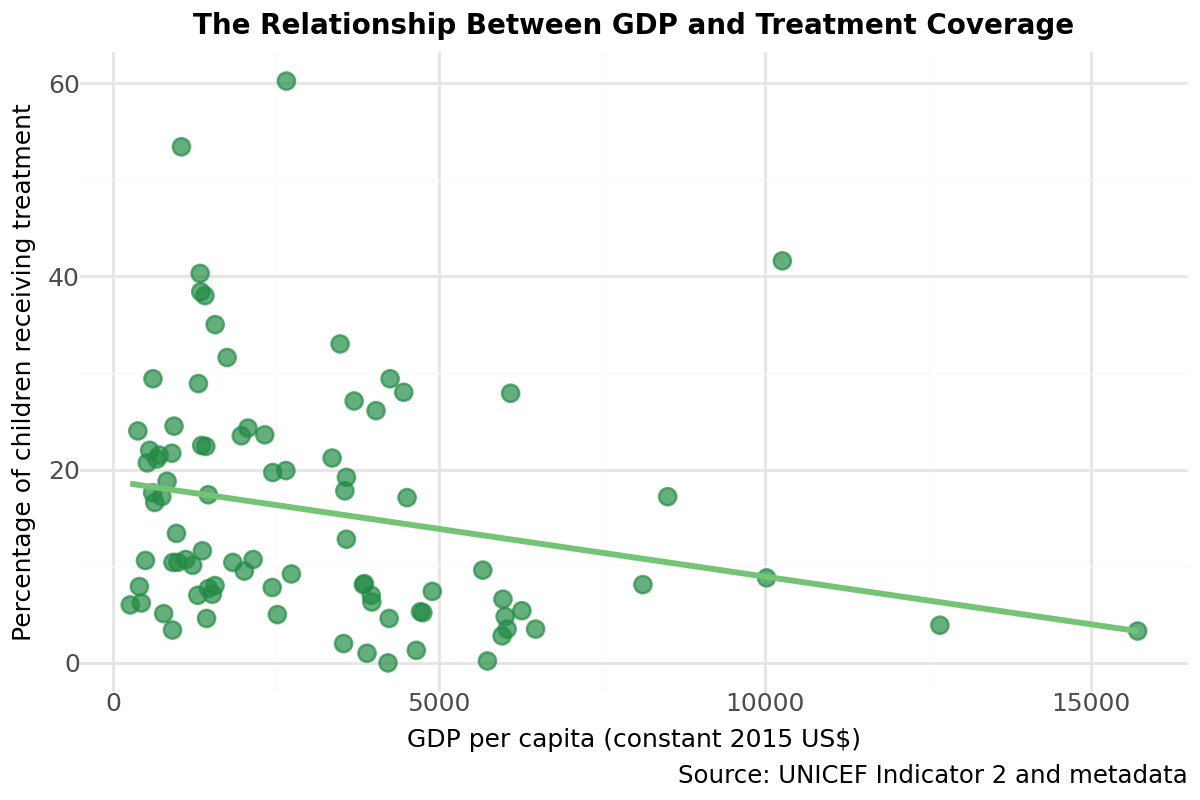

In [ ]:
#| echo: false
#| fig-cap: "The relationship between GDP per capita and treatment coverage is weak, suggesting that wealth alone does not guarantee better access to treatment."
#| label: fig-scatter
import polars as pl
from plotnine import ggplot, aes, geom_point, geom_smooth, labs, theme_minimal, element_text, theme

# Re-create scatter_data to ensure it's defined in the current scope
# assuming 'latest_country' and 'metadata' DataFrames are already in the kernel's memory

# Explicitly load metadata
metadata = pl.read_csv("/content/unicef_metadata.csv")

scatter_data = latest_country.join(
    metadata,
    on=["country", "year"],
    how="inner"
)

scatter_data = scatter_data.drop_nulls(
    ["GDP per capita (constant 2015 US$)", "obs_value"]
)
(
    ggplot(
        scatter_data.to_pandas(),
        aes(
            x="GDP per capita (constant 2015 US$)",
            y="obs_value"
        )
    )
    + geom_point(size=3, color="#238B45", alpha=0.7)
    + geom_smooth(method="lm", se=False, color="#74C476", size=1.2)
    + labs(
        title="The Relationship Between GDP and Treatment Coverage",
        x="GDP per capita (constant 2015 US$)",
        y="Percentage of children receiving treatment",
        caption="Source: UNICEF Indicator 2 and metadata"
    )
    + theme_minimal()
    + theme(
        figure_size=(6,4),
        plot_title=element_text(size=10, weight="bold"),
        plot_subtitle=element_text(size=9),
        axis_title=element_text(size=9),
        axis_text=element_text(size=9)
    )
)

The scatterplot shows a weak relationship between GDP per capita and treatment coverage. Some lower income countries achieve relatively high treatment rates, while several wealthier countries continue to report lower coverage. This suggests that income alone does not determine whether children receive life saving treatment. Differences in public health policy, healthcare access, and investment in child health appear to matter just as much, if not more.

![Oral rehydration salts can prevent most deaths from diarrhoea when treatment is available in time.](ors_treatment.png)

In [ ]:
from IPython.display import HTML

HTML('<hr style="border: none; height: 2px; background: linear-gradient(to right, #66bb6a, #c8e6c9); margin-top: 0.5rem; margin-bottom: 0.5rem;">')

In [ ]:
#| include: false
selected = (
    indicator
    .filter(
        (pl.col("sex") == "Total") &
        (pl.col("country").is_in(["Zambia", "Lesotho", "Mali"]))
    )
    .select(["country", "time_period", "obs_value"])
)

## ⏳ Changes in Treatment Coverage Over Time

Treatment coverage has not improved at the same pace across countries. The final chart follows Lesotho, Mali, and Zambia because each represents a different pattern of change over time. Together, they show that progress in access to life saving treatment is often uneven.

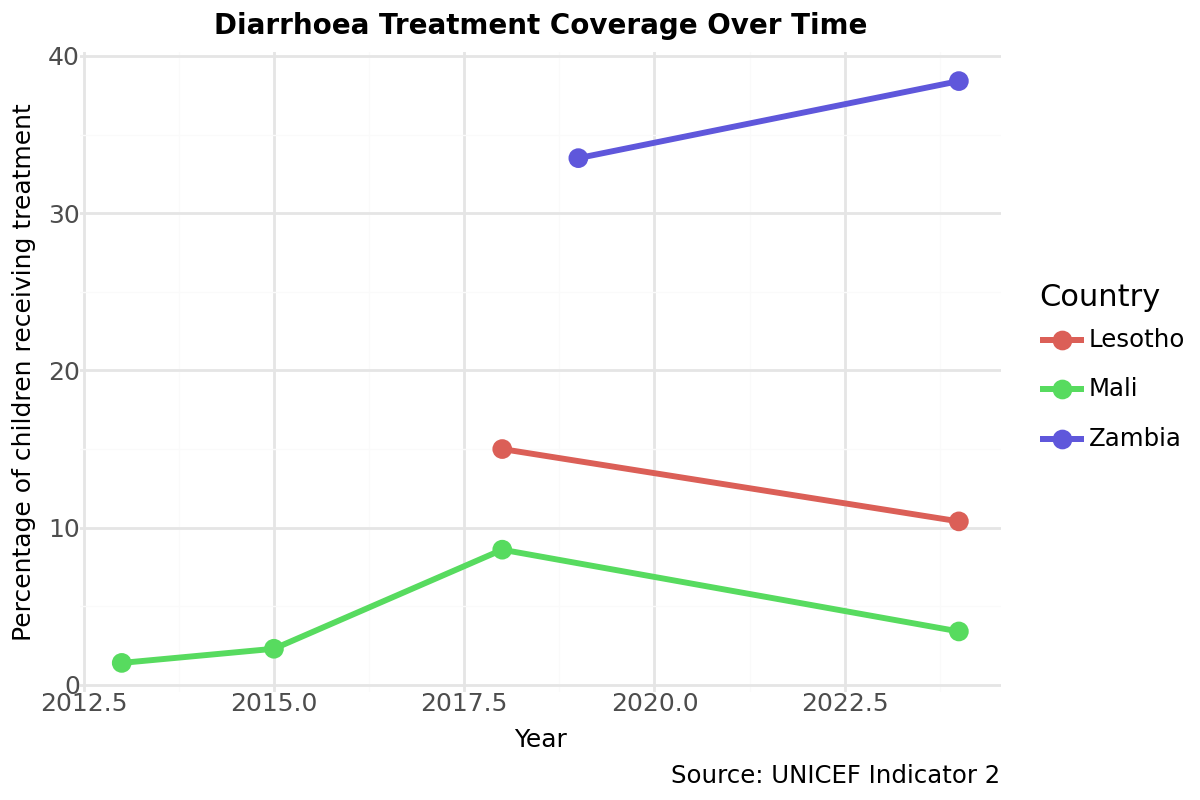

In [ ]:
#| echo: false
#| fig-cap: "Treatment coverage improved steadily in Zambia but declined in Lesotho and Mali, showing that progress is uneven across countries."
#| label: fig-time
import polars as pl
from plotnine import ggplot, aes, geom_line, geom_point, labs, theme_minimal, element_text

indicator = pl.read_csv("/content/unicef_indicator_2.csv")
metadata = pl.read_csv("/content/unicef_metadata.csv")

selected = (
    indicator
    .filter(
        (pl.col("sex") == "Total") &
        (pl.col("country").is_in(["Zambia", "Lesotho", "Mali"]))
    )
    .select(["country", "time_period", "obs_value"])
)

(
    ggplot(
        selected.to_pandas(),
        aes(
            x="time_period",
            y="obs_value",
            color="country",
            group="country"
        )
    )
    + geom_line(size=1.2)
    + geom_point(size=3)
    + labs(
        title="Diarrhoea Treatment Coverage Over Time",
        x="Year",
        y="Percentage of children receiving treatment",
        color="Country",
        caption="Source: UNICEF Indicator 2"
    )
    + theme_minimal()
    + theme(
        figure_size=(6,4),
        plot_title=element_text(size=10, weight="bold"),
        plot_subtitle=element_text(size=9),
        axis_title=element_text(size=9),
        axis_text=element_text(size=9),
        legend_position="right"
    )
)

Zambia shows a steady increase in treatment coverage, rising from 33.5 percent in 2019 to 38.4 percent in 2024. In contrast, Lesotho and Mali both experienced declines over the same period. These differing trends highlight that progress is not guaranteed and can vary considerably between countries. Changes in healthcare investment, government priorities, public awareness, and access to basic treatment may all influence whether coverage improves or worsens over time.

![Access to treatment depends not only on income, but also on the availability of healthcare services and medical supplies.](medical_treatment.jpg)

In [ ]:
from IPython.display import HTML

HTML('<hr style="border: none; height: 2px; background: linear-gradient(to right, #66bb6a, #c8e6c9); margin-top: 0.5rem; margin-bottom: 0.5rem;">')

## ❌ Myth vs Reality

**Myth:** Wealthier countries always provide better treatment.  
**Reality:** Several lower income countries report higher treatment coverage than wealthier nations.

## 🌱 Conclusion

Despite being inexpensive and highly effective, diarrhoea treatment remains out of reach for many children around the world. The data reveal large differences in access between countries, with some achieving relatively high treatment coverage while others continue to leave many children without care.

These patterns suggest that improving child health depends on more than national income alone. Access to life saving treatment is also influenced by healthcare systems, public policy, and the availability of oral rehydration salts and zinc. Ensuring that more children receive treatment will require continued attention to child health, stronger health services, and sustained investment in affordable care.

In [ ]:
from IPython.display import HTML

HTML("""
<div style="display:flex; justify-content:center; align-items:center; gap:20px; margin-top:30px;">

  <a href="https://www.unicef.ie/donate/child-survival-appeal/?src=SEARCH&ch=DP&gad_source=1&gad_campaignid=22648694594&gbraid=0AAAAADuWl6RlNYsOuVmZpFOz2bxJ0cxNo&gclid=Cj0KCQjwp7jOBhDGARIsABe7C4dK4wQ7JIotd_truJlN2Tk1QENIGY5ThYtgSK2Im86ebeRco--OPDoaAoFNEALw_wcB" target="_blank">
    <img src="unicef_logo.png" style="height:40px;">
  </a>

  <a href="https://www.facebook.com/unicef/" target="_blank">
    <img src="facebook.png" style="width:32px; height:32px;">
  </a>

  <a href="https://www.instagram.com/unicef/" target="_blank">
    <img src="instagram.png" style="width:32px; height:32px;">
  </a>

  <a href="https://linkedin.com/company/unicef" target="_blank">
    <img src="linkedin.png" style="width:32px; height:32px;">
  </a>

</div>
""")

In [ ]:
from IPython.display import HTML

HTML('<div style="text-align:center; font-size:0.9rem; color:#777; margin-top:3rem;">Created by Laniqua Hendricks • Data source: UNICEF and World Bank</div>')

In [ ]:
#| include: false
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#| include: false
!ls "/content/drive/MyDrive/Colab Notebooks"

UNICEF_Assignment_Final  UNICEF_Assignment.ipynb  Untitled1_files
UNICEF_Assignment.html	 Untitled0_files


In [ ]:
#| include: false
!quarto render "/content/drive/MyDrive/Colab Notebooks/UNICEF_Assignment.ipynb"

pandoc 
  to: html
  output-file: UNICEF_Assignment.html
  standalone: true
  embed-resources: true
  section-divs: true
  html-math-method: mathjax
  wrap: none
  default-image-extension: png
  number-sections: false
  toc: true
  variables: {}
  
metadata
  document-css: false
  link-citations: true
  date-format: long
  lang: en
  engines:
    - path: /usr/local/lib/python3.12/dist-packages/quarto_cli/share/extension-subtrees/julia-engine/_extensions/julia-engine/julia-engine.js
  title: 🌍 A Global Gap in Access to Life-Saving Treatment
  author: Laniqua Hendricks
  theme: cosmo
  
[WARNING] Could not fetch resource child_treatment.jpg
[WARNING] Could not fetch resource ors_treatment.png
[WARNING] Could not fetch resource medical_treatment.jpg
[WARNING] Could not fetch resource unicef_logo.png
[WARNING] Could not fetch resource facebook.png
[WARNING] Could not fetch resource instagram.png
[WARNING] Could not fetch resource linkedin.png
Output created: UNICEF_Assignment.html

